<a href="https://colab.research.google.com/github/qu1r0ra/jute-disease-detection/blob/Imman-patch/notebooks/reproducibility/03_Model_Analysis_Tuning_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **IV. EXPERIMENTS AND RESULTS**
## Classical Machine Learning Model Analysis and Tuning
This notebook covers the detailed evaluation of the two distinguished model from the previous notebook (SVM and RF), followed by fine-tuning process.


## Environment Setup

In [ ]:
!git clone https://github.com/qu1r0ra/jute-disease-detection.git
%cd jute-disease-detection


%pip install uv
!uv pip install --system -e .
!uv sync

fatal: destination path 'jute-disease-detection' already exists and is not an empty directory.
/content/jute-disease-detection
Using Python 3.12.13 environment at: /usr
Resolved 109 packages in 1.59s
Prepared 1 package in 1.45s
Uninstalled 1 package in 1ms
Installed 1 package in 2ms
 ~ jute-disease-detection==0.1.0 (from file:///content/jute-disease-detection)
Resolved 183 packages in 3ms
Checked 176 packages in 170ms


If you encounter `ModuleNotFoundError`, you can simply restart the session and rerun the cell below.

In [1]:
# ruff: noqa: T201
from jute_disease.utils.constants import DEFAULT_SEED
from jute_disease.utils.seed import seed_everything

seed_everything(DEFAULT_SEED)

INFO: Seed set to 42
INFO:lightning.fabric.utilities.seed:Seed set to 42


Mount your Google Drive to the Colab runtime.

In [2]:
from google.colab import drive

drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


If you haven't yet,

1. Download `data.zip` from <https://drive.google.com/drive/folders/1WoQ-Xzy0Prl9lInHW5JpGX4tpE9YDUua?usp=sharing> and upload it to your Google Colab account's Google Drive. You can simply upload it to the root of _My Drive_ for simplicity.
2. Update `DATA_ZIP_PATH` below to the path where you stored the file. If you uploaded it to the root of _My Drive_, you can set it to **"/content/drive/MyDrive/data.zip"**.

In [ ]:
%ls

AGENTS.md   configs/  LICENSE     pyproject.toml  scripts/  uv.lock
artifacts/  data/     Makefile    README.md       src/      wandb/
assets/     docs/     notebooks/  ruff.toml       tests/


In [ ]:
%cd jute-disease-detection/

[Errno 2] No such file or directory: 'jute-disease-detection/'
/content/jute-disease-detection


In [ ]:
# make sure that the current directory is as
from pathlib import Path

# Update DATA_ZIP_PATH to where data.zip is stored relative to the Colab VM filesystem.
# For organization, we stored ours in!uv pip install --system -e .
# "/content/drive/MyDrive/Colab Notebooks/Jute Leaf Disease/data.zip"
DATA_ZIP_PATH = "/content/drive/MyDrive/data.zip"
DEST_PATH = Path("data/by_class")

if Path(DATA_ZIP_PATH).exists():
    DEST_PATH.mkdir(parents=True, exist_ok=True)
    print(f"Unzipping {DATA_ZIP_PATH} to {DEST_PATH}...")
    !unzip -q -n "$DATA_ZIP_PATH" -d "$DEST_PATH"
    print("Data unpacked.")
else:
    print(
        f"Zip file not found at {DATA_ZIP_PATH}. "
        "Please check the path or upload your data."
    )

Unzipping /content/drive/MyDrive/data.zip to data/by_class...
Data unpacked.


Let's cleanly construct the `train`, `val`, and `test` sub-folders inside `data/ml_split/` from your unzipped files.

In [ ]:
!uv run python src/jute_disease/data/utils.py split

Seed set to 42
2026-03-20 07:36:25,589 - jute_disease.utils.seed - INFO - Random seed set to: 42
2026-03-20 07:36:25,590 - __main__ - INFO - Split directory /content/jute-disease-detection/data/ml_split already exists. Skipping split.


To persist our training artifacts beyond the Colab VM, we can _symlink_ the `artifacts` folder directly to our Google Drive.

In [ ]:
GDRIVE_PATH = Path(DATA_ZIP_PATH).parent
GDRIVE_ARTIFACTS = GDRIVE_PATH / "artifacts"
GDRIVE_ARTIFACTS.mkdir(parents=True, exist_ok=True)

LOCAL_ARTIFACTS = Path("artifacts")

if not LOCAL_ARTIFACTS.exists() and not LOCAL_ARTIFACTS.is_symlink():
    LOCAL_ARTIFACTS.symlink_to(GDRIVE_ARTIFACTS)
    print(f"Symlinked {LOCAL_ARTIFACTS.absolute()} to {GDRIVE_ARTIFACTS}")
else:
    print(f"{LOCAL_ARTIFACTS} already exists or is linked.")

artifacts already exists or is linked.


Let us perform a quick sanity test to ensure all generated files show up inside your Google Drive folder containing your `data.zip`. If you see a generated `test.txt` file then you are all set to proceed.

In [ ]:
test_file = LOCAL_ARTIFACTS / "test.txt"
test_file.write_text("ML model selection test.")

if (GDRIVE_ARTIFACTS / "test.txt").exists():
    print("Symlink worked.")
else:
    print("Symlink failed :<")

Symlink worked.


Lastly, before we move on to the actual experimentation process, let's import the necessary tools that we will be using.

In [3]:
import wandb
import pandas as pd
import matplotlib.pyplot as plt
import os
import seaborn as sns
import matplotlib.pyplot as plt
import json
import joblib
import numpy as np

from torchvision.datasets import ImageFolder
from torchvision import transforms
from matplotlib.lines import Line2D
from pathlib import Path
from sklearn.manifold import TSNE
from umap import UMAP
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, learning_curve
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score,  precision_recall_fscore_support
from tqdm import tqdm

from jute_disease.utils import WANDB_PROJECT, WANDB_ENTITY, get_logger
from jute_disease.models.ml.features import CraftedFeatureExtractor



## **Part 1: Baseline Analysis**
### **1A. Quantitative Performance**

We will summarize the performance metrics and visualize the training dynamics for both our SVM and RF models which were trained on handcrafted features (color, LBP, and HOG) with baseline standard scaling applied. To start, we will first retrieve the trained crafted RF and SVM models from our `WANDB` project and review our baseline metrics.

**NOTES**:
- The current configuration of the filter condition is set such that it will only take the model runs that are tagged as "experiment".
- You may be asked to provide your `WANDB` API key if you do not have access to the `.env` file from the authors.

In [4]:

#predefined ids
target_runs = {
    "RF": "a1vp3q52",
    "SVM": "5g1zzwvm"
}

api_key = os.environ.get("WANDB_API_KEY")
if api_key:
    wandb.login(key=api_key)
else:
    print("API key not found.")

api = wandb.Api()
project_path = "grade-descent/jute-disease-detection"
summary_list = []

for model_type, run_id in target_runs.items():
    try:
        run = api.run(f"{project_path}/{run_id}")

        summary_list.append({
            "Model": model_type,
            "Feature_Type": run.config.get("feature_type", "crafted"),
            "Val Accuracy": run.summary.get("val_acc"),
            "Val F1-Score": run.summary.get("val_f1"),
            "Run_ID": run.id
        })
    except Exception as e:
        print(f"Error fetching run {run_id}: {e}")

df_ml_comparison = pd.DataFrame(summary_list)

df_ml_comparison['Model'] = df_ml_comparison['Model'].astype(str)

pd.options.display.float_format = '{:.4f}'.format
output_path = Path("artifacts/ml_baseline_comparison.csv")
output_path.parent.mkdir(parents=True, exist_ok=True)
df_ml_comparison.to_csv(output_path, index=False)

print(f"Table saved to: {output_path.absolute()}")
display(df_ml_comparison)
wandb.finish()

API key not found.


wandb: [wandb.Api()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


Table saved to: /content/artifacts/ml_baseline_comparison.csv


,Model,Feature_Type,Val Accuracy,Val F1-Score,Run_ID
0,RF,crafted,0.7697,0.7469,a1vp3q52
1,SVM,crafted,0.7022,0.7173,5g1zzwvm


Shown above are the test accuracies and F1-Scores of the baseline models for the Random Forest (RF) and Support Vector Machine (SVM) Classifier. The shown test accuracy and F1-score will serve as a baseline later after we have tuned our model.

### **1B. Error Analysis**

We begin by creating a confusion matrix that which will allow us to investigate which disease classes are most often mistaken by the model. The code below allows us to filter for the correct RF and SVM baseline model that we will be focusing on for our error analysis.

In [5]:
# Filters for the crafted Rf and SVM runs
rf_crafted_id = df_ml_comparison[
    (df_ml_comparison['Model'].str.lower() == 'rf') &
    (df_ml_comparison['Feature_Type'] == 'crafted')
]['Run_ID'].values[0]

svm_crafted_id = df_ml_comparison[
    (df_ml_comparison['Model'].str.lower() == 'svm') &
    (df_ml_comparison['Feature_Type'] == 'crafted')
]['Run_ID'].values[0]

Given that our next goal is to create the confusion matrix for our baseline models, it would be much easier for us to start off by creating a dataframe for it. Luckily, we can simply fetch it from the `WANDB` artifacts as JSON data.

In [91]:
%ls

AGENTS.md   configs/  LICENSE     pyproject.toml  scripts/  uv.lock
artifacts/  data/     Makefile    README.md       src/      wandb/
assets/     docs/     notebooks/  ruff.toml       tests/


wandb: Currently logged in as: immanumali12 (immanumali12-de-la-salle-university) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Loading local model from: /content/drive/MyDrive/artifacts/ml_models/rf_crafted.joblib


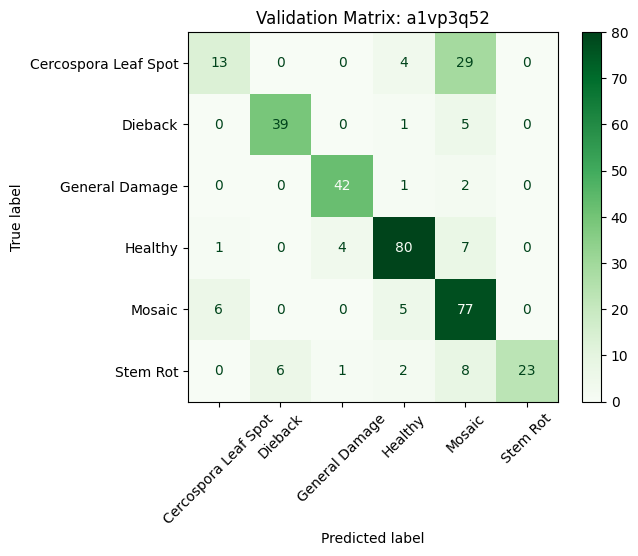

test_acc,0.72222
test_f1,0.67471
test_precision,0.73051
test_recall,0.68381
val_acc,0.76966
val_f1,0.74694
val_precision,0.81201
val_recall,0.7337


Loading local model from: /content/drive/MyDrive/artifacts/ml_models/svm_crafted.joblib


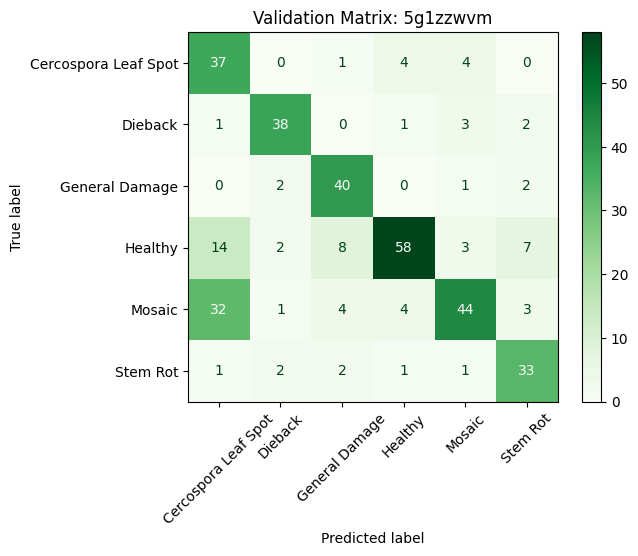

test_acc,0.66944
test_f1,0.68071
test_precision,0.68136
test_recall,0.71632
val_acc,0.70225
val_f1,0.71734
val_precision,0.72463
val_recall,0.74885


In [6]:
CLASS_NAMES = ["Cercospora Leaf Spot", "Dieback", "General Damage", "Healthy", "Mosaic", "Stem Rot"]
FEATURE_DIR = Path("/content/drive/MyDrive/artifacts/features/")

def generate_val_confusion_matrix(run_id, local_model_path):
    if wandb.run is not None:
        wandb.finish()

    run = wandb.init(
        entity="grade-descent",
        project="jute-disease-detection",
        id=run_id,
        resume="allow",
        job_type="evaluation"
    )

    print(f"Loading local model from: {local_model_path}")
    model = joblib.load(local_model_path)

    X_val = np.load(FEATURE_DIR / "craftedfeatureextractor_val_X.npy")
    y_val = np.load(FEATURE_DIR / "craftedfeatureextractor_val_y.npy")

    y_val_cleaned = np.where(y_val == 6, 0, y_val)

    preds = model.predict(X_val)

    run.log({
        "val_conf_mat_table": wandb.plot.confusion_matrix(
            preds=preds,
            y_true=y_val_cleaned,
            class_names=CLASS_NAMES
        )
    })

    from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
    cm = confusion_matrix(y_val_cleaned, preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_NAMES)
    disp.plot(cmap='Greens', xticks_rotation=45)
    plt.title(f"Validation Matrix: {run_id}")
    plt.show()

    run.finish()


RF_PATH = "/content/drive/MyDrive/artifacts/ml_models/rf_crafted.joblib"
SVM_PATH = "/content/drive/MyDrive/artifacts/ml_models/svm_crafted.joblib"

generate_val_confusion_matrix(rf_crafted_id, RF_PATH)
generate_val_confusion_matrix(svm_crafted_id, SVM_PATH)

In [7]:
def get_confusion_df(run_id, model_name):
    run = api.run(f"{project_path}/{run_id}")
    artifacts = run.logged_artifacts()

    possible_names = ["val_conf_mat_table"]

    table_artifact = None
    for name in possible_names:
        matches = [a for a in artifacts if name in a.name]
        if matches:
            table_artifact = matches[0]
            break

    if not table_artifact:
        available = [a.name for a in artifacts]
        raise ValueError(f"No confusion matrix found for Run {run_id}. Available artifacts: {available}")

    table_dir = table_artifact.download()
    json_path = next(Path(table_dir).glob("*.json"))

    with open(json_path) as f:
        data = json.load(f)

    df = pd.DataFrame(data["data"], columns=data["columns"])

    val_col = "n" if "n" in df.columns else "nPredictions"
    df = df.rename(columns={val_col: f"{model_name}_Count"})

    return df[['Actual', 'Predicted', f"{model_name}_Count"]]

rf_counts = get_confusion_df(rf_crafted_id, "RF")
svm_counts = get_confusion_df(svm_crafted_id, "SVM")

comparison_table = pd.merge(rf_counts, svm_counts, on=['Actual', 'Predicted'], how='outer').fillna(0)
comparison_table['RF_Count'] = comparison_table['RF_Count'].astype(int)
comparison_table['SVM_Count'] = comparison_table['SVM_Count'].astype(int)
comparison_table['Status'] = comparison_table.apply(
    lambda x: "CORRECT" if x['Actual'] == x['Predicted'] else "WRONG", axis=1
)

comparison_table = comparison_table.sort_values(by=['Actual'], ascending=[True])
display(comparison_table)

wandb:   1 of 1 files downloaded.  
wandb:   1 of 1 files downloaded.  


,Actual,Predicted,RF_Count,SVM_Count,Status
0,Cercospora Leaf Spot,Cercospora Leaf Spot,13,37,CORRECT
1,Cercospora Leaf Spot,Dieback,0,0,WRONG
2,Cercospora Leaf Spot,General Damage,0,1,WRONG
3,Cercospora Leaf Spot,Healthy,4,4,WRONG
4,Cercospora Leaf Spot,Mosaic,29,4,WRONG
5,Cercospora Leaf Spot,Stem Rot,0,0,WRONG
6,Dieback,Cercospora Leaf Spot,0,1,WRONG
7,Dieback,Dieback,39,38,CORRECT
8,Dieback,General Damage,0,0,WRONG
9,Dieback,Healthy,1,1,WRONG


The table above shows a confusion matrix which contains all the possible configurations of the actual and predicted class. Along with it we can see the number of correct and wrong classifications the baseline RF and SVM classifiers made. Looking at this as such, it can be difficult to visualize how much were correctly and incorrectly classified, so let's tackle that.

We then visualize our data as the following:

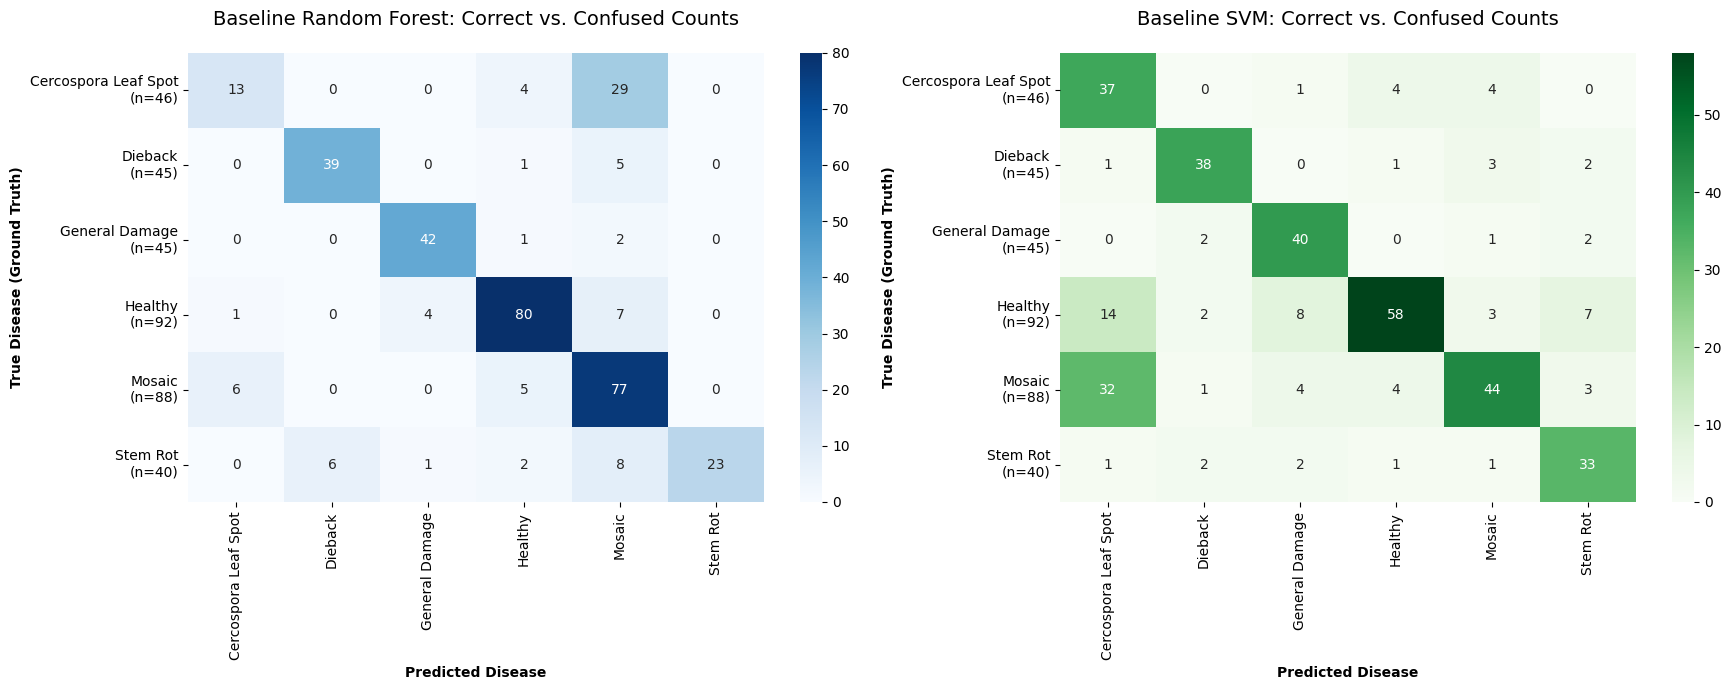

In [8]:
# Confusion matrix visualization setup adopted from:
# https://www.geeksforgeeks.org/machine-learning/how-to-plot-confusion-matrix-with-labels-in-sklearn/

def plot_normalized_confusion_matrices(df):
    rf_matrix = df.pivot(index='Actual', columns='Predicted', values='RF_Count').fillna(0)
    svm_matrix = df.pivot(index='Actual', columns='Predicted', values='SVM_Count').fillna(0)

    class_totals = rf_matrix.sum(axis=1).astype(int)
    new_labels = [f"{cls}\n(n={total})" for cls, total in class_totals.items()]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

    sns.heatmap(rf_matrix, annot=True, fmt='g', cmap='Blues', ax=ax1,
                yticklabels=new_labels, xticklabels=rf_matrix.columns)
    ax1.set_title('Baseline Random Forest: Correct vs. Confused Counts', fontsize=14, pad=20)
    ax1.set_xlabel('Predicted Disease', fontweight='bold')
    ax1.set_ylabel('True Disease (Ground Truth)', fontweight='bold')

    sns.heatmap(svm_matrix, annot=True, fmt='g', cmap='Greens', ax=ax2,
                yticklabels=new_labels, xticklabels=svm_matrix.columns)
    ax2.set_title('Baseline SVM: Correct vs. Confused Counts', fontsize=14, pad=20)
    ax2.set_xlabel('Predicted Disease', fontweight='bold')
    ax2.set_ylabel('True Disease (Ground Truth)', fontweight='bold')

    plt.tight_layout()

    plt.savefig("artifacts/ml_confusion_matrix_with_n_counts.png", dpi=300)
    plt.show()

# Run the visualization
plot_normalized_confusion_matrices(comparison_table)

The figures shown above are the visualized confusion matrix for both RF-craft and SVM-crafted. Upon initial inspection of the figures, it appears that the `Healthy` class is often correctly classified as it is distinguished for it high values. However, we may have to take into account that the `Healthy` class also contains the most amount of sample images which makes it seem as being the most often correctly classified. With regards to the misclassification, the RF model indicates that it misclassified `Cercospora Leaf Spots` the most as `Mosaic` (n=29). Interestingly, it would appear that for the baseline SVM model, it misclassified `Mosaic` as `Cercospora Leaf Spots` the most (n=32).

In order to get a better understanding of the performance of the model classification, we have to look into its corresponding metrics, specfically, accuracy, precision, recall, and F1-score.

In [9]:
FEATURE_DIR = Path("/content/drive/MyDrive/artifacts/features/")
RF_PATH = "/content/drive/MyDrive/artifacts/ml_models/rf_crafted.joblib"
SVM_PATH = "/content/drive/MyDrive/artifacts/ml_models/svm_crafted.joblib"

print("Loading pre-extracted features...")
X_val = np.load(FEATURE_DIR / "craftedfeatureextractor_val_X.npy")
y_val = np.load(FEATURE_DIR / "craftedfeatureextractor_val_y.npy")

print("Loading champion models...")
rf_model = joblib.load(RF_PATH)
svm_model = joblib.load(SVM_PATH)

print(f"Running batch inference on {X_val.shape[0]} samples...")

rf_preds = rf_model.predict(X_val)
rf_probas = rf_model.predict_proba(X_val)

svm_preds = svm_model.predict(X_val)
svm_probas = svm_model.predict_proba(X_val)

targets = y_val
y_val_labels = y_val

Loading pre-extracted features...
Loading champion models...
Running batch inference on 356 samples...


In [11]:
def generate_metrics_table(y_true, y_pred, model_name):
    class_names = ["Cercospora Leaf Spot", "Dieback", "General Damage", "Healthy", "Mosaic", "Stem Rot"]

    report = classification_report(y_true, y_pred, target_names=class_names, output_dict=True)

    cm = confusion_matrix(y_true, y_pred)
    total_samples = cm.sum()
    per_class_accuracy = []

    for i in range(len(class_names)):
        tp = cm[i, i]
        fp = cm[:, i].sum() - tp
        fn = cm[i, :].sum() - tp
        tn = total_samples - (tp + fp + fn)
        accuracy = (tp + tn) / total_samples
        per_class_accuracy.append(accuracy)

    data = []
    for i, cls in enumerate(class_names):
        data.append({
            "Class": cls,
            "Accuracy": per_class_accuracy[i],
            "Precision": report[cls]["precision"],
            "Recall": report[cls]["recall"],
            "F1-Score": report[cls]["f1-score"],
            "Support": int(report[cls]["support"])
        })

    df = pd.DataFrame(data)
    df_styled = df.round(4)

    print(f"\nClassification Metrics by Class ({model_name})")
    display(df_styled)

    df_styled.to_csv(f"artifacts/metrics_{model_name.lower().replace(' ', '_')}.csv", index=False)

    return df_styled

rf_metrics_df = generate_metrics_table(y_val, rf_preds, "Random Forest")
svm_metrics_df = generate_metrics_table(y_val, svm_preds, "SVM")


Classification Metrics by Class (Random Forest)


,Class,Accuracy,Precision,Recall,F1-Score,Support
0,Cercospora Leaf Spot,0.8876,0.6500,0.2826,0.3939,46
1,Dieback,0.9663,0.8667,0.8667,0.8667,45
2,General Damage,0.9775,0.8936,0.9333,0.9130,45
3,Healthy,0.9298,0.8602,0.8696,0.8649,92
4,Mosaic,0.8258,0.6016,0.8750,0.7130,88
5,Stem Rot,0.9522,1.0000,0.5750,0.7302,40



Classification Metrics by Class (SVM)


,Class,Accuracy,Precision,Recall,F1-Score,Support
0,Cercospora Leaf Spot,0.8399,0.4353,0.8043,0.5649,46
1,Dieback,0.9607,0.8444,0.8444,0.8444,45
2,General Damage,0.9438,0.7273,0.8889,0.8000,45
3,Healthy,0.8764,0.8529,0.6304,0.7250,92
4,Mosaic,0.8427,0.7857,0.5000,0.6111,88
5,Stem Rot,0.9410,0.7021,0.8250,0.7586,40


Some insights:
- For **both baseline models**, `Dieback`, `General Damage`, and `Stem Rot` images were classified with the highest accuracy among the five class acheiving at least ~94%.
- The RF model appears to have struggled in classifying `Cercospora Leaf Spots` given that its F1-score is noticably lower as compared to the other five. Additionally, the recall for this is noticably low as given that it was measured to be 28.26% which in constast is noticeably lower that its precision of 65.00%.
  - This suggests that the baseline RF is somewhat skeptical in classifying this type of jute leaf images which may also explain why it has such a low recall value.   
- The SVM classifier seems to also have struggled classifiying `Mosaic` and `Cercospora Leaf Spots` as these classses were the only two that had an F1-score lower than 70% among the six classes.
  - It is worth noting this interesting relationship between these two classes given their precision and recall values somewhat resembles each other such that it complements each other being approximately ~43% and ~80% for `Cercospora Leaf Spots` while the Mosaic had approximately ~78% and ~50% precision and recall respectively.
- Furthermore, both RF and SVM had noticably low metrics, specifically RF having low recall for `Cercospora Leaf Spot` while SVM has low precision for the same class, as well as low recall for `Mosaic`.
- Another metric worth noting is SVM's recall value for `Mosaic` which is indicated as 50%. This appears to be noticably low compared to the other classes.
  - This suggests that the baseline SVM classifier struggles in correctly identifying `Mosaic` instances.

  ---
  Given these insights, it is worth investigating the how these baseline models came to these predictions. To do so, we will try to investigate further on this matter through looking into the features that were considered and our impression of the images that were misclassified.


### Model Inference Setup
The following sections will tackle latent space analysis, feature importance, and interpretability which requires both RF and SVM models' test set predictions as well as the crafted features used. Therefore we begin our Model Inference Setup as follows:

In [69]:
# #

# TEST_DIR = "/content/jute-disease-detection/data/ml_split/test"

# ml_transform = transforms.Compose([
#     transforms.Resize((256,256)),
#     transforms.Lambda(lambda x: np.array(x))
# ])

# # Use only ml_test
# ml_test = ImageFolder(root=TEST_DIR, transform=ml_transform)
# y_test_labels = np.array(ml_test.targets)
# extractor = CraftedFeatureExtractor()

# all_rf_preds, all_rf_probas = [], []
# all_svm_preds, all_svm_probas = [], []
# all_targets = []

# print(f"Running inference on {len(ml_test)} test images...")
# for img, label in tqdm(ml_test):
#     feat = extractor.extract(img).reshape(1, -1)

#     all_rf_preds.append(rf_model.predict(feat)[0])
#     all_rf_probas.append(rf_model.predict_proba(feat)[0])

#     all_svm_preds.append(svm_model.predict(feat)[0])
#     all_svm_probas.append(svm_model.predict_proba(feat)[0])

#     all_targets.append(label)

# rf_preds = np.array(all_rf_preds)
# rf_probas = np.array(all_rf_probas)
# svm_preds = np.array(all_svm_preds)
# svm_probas = np.array(all_svm_probas)
# targets = np.array(all_targets)

### Top Confident Errors
Let's visualize the model's top confident errors to analyze the images and classes it struggles with.

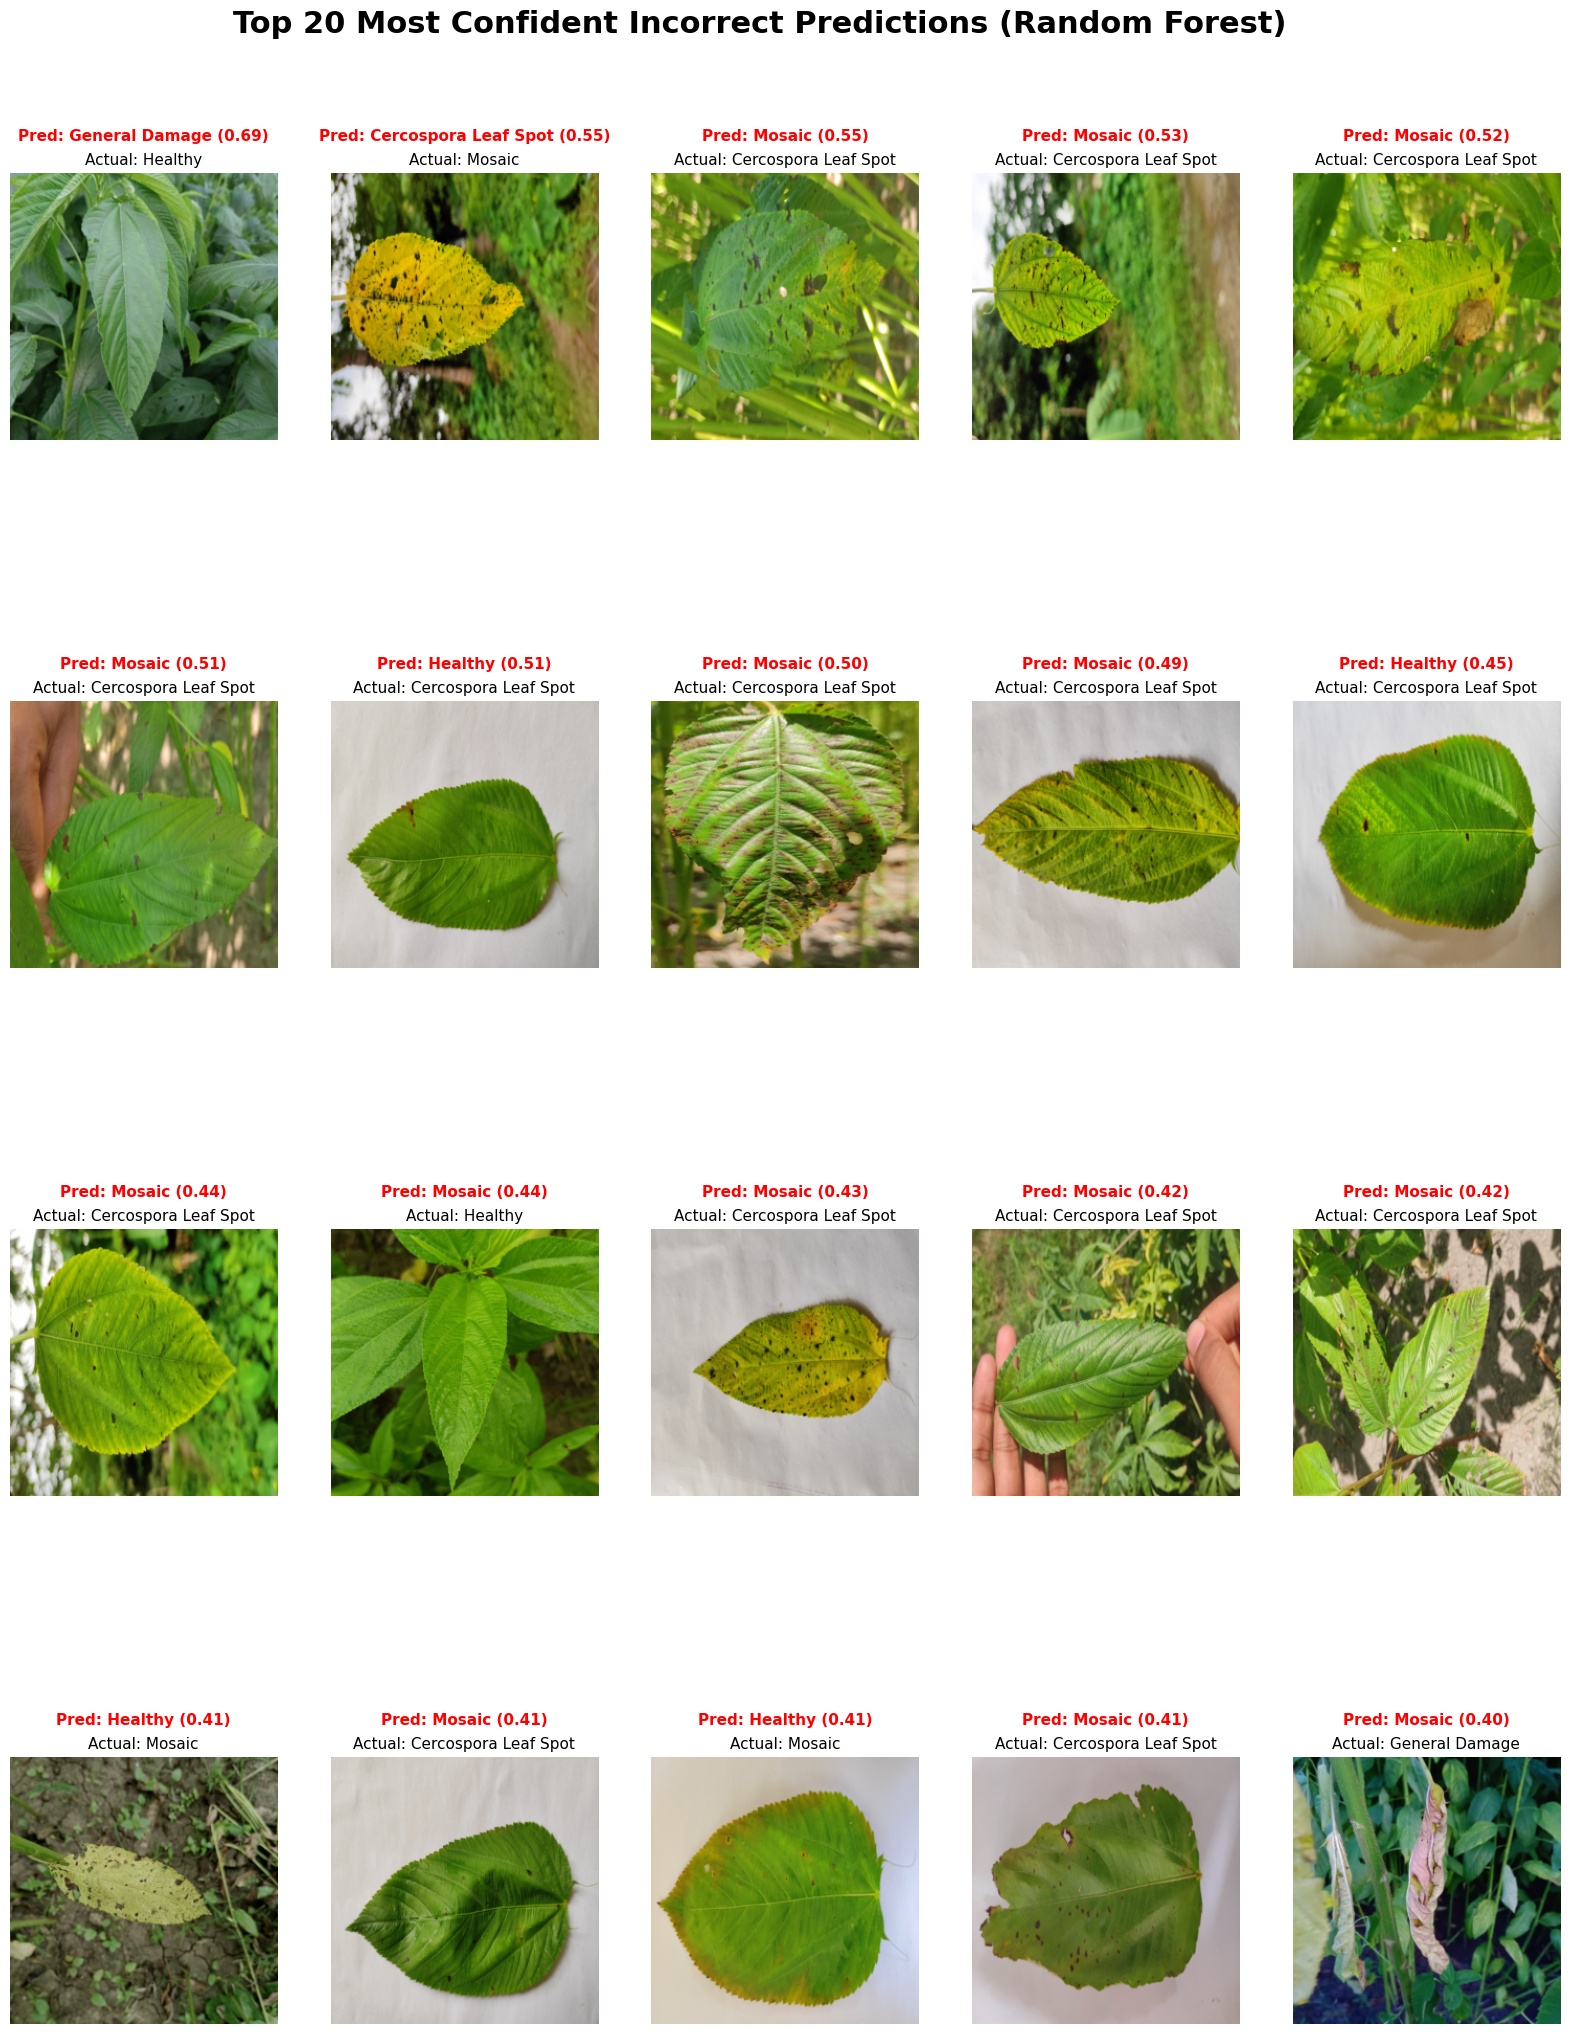

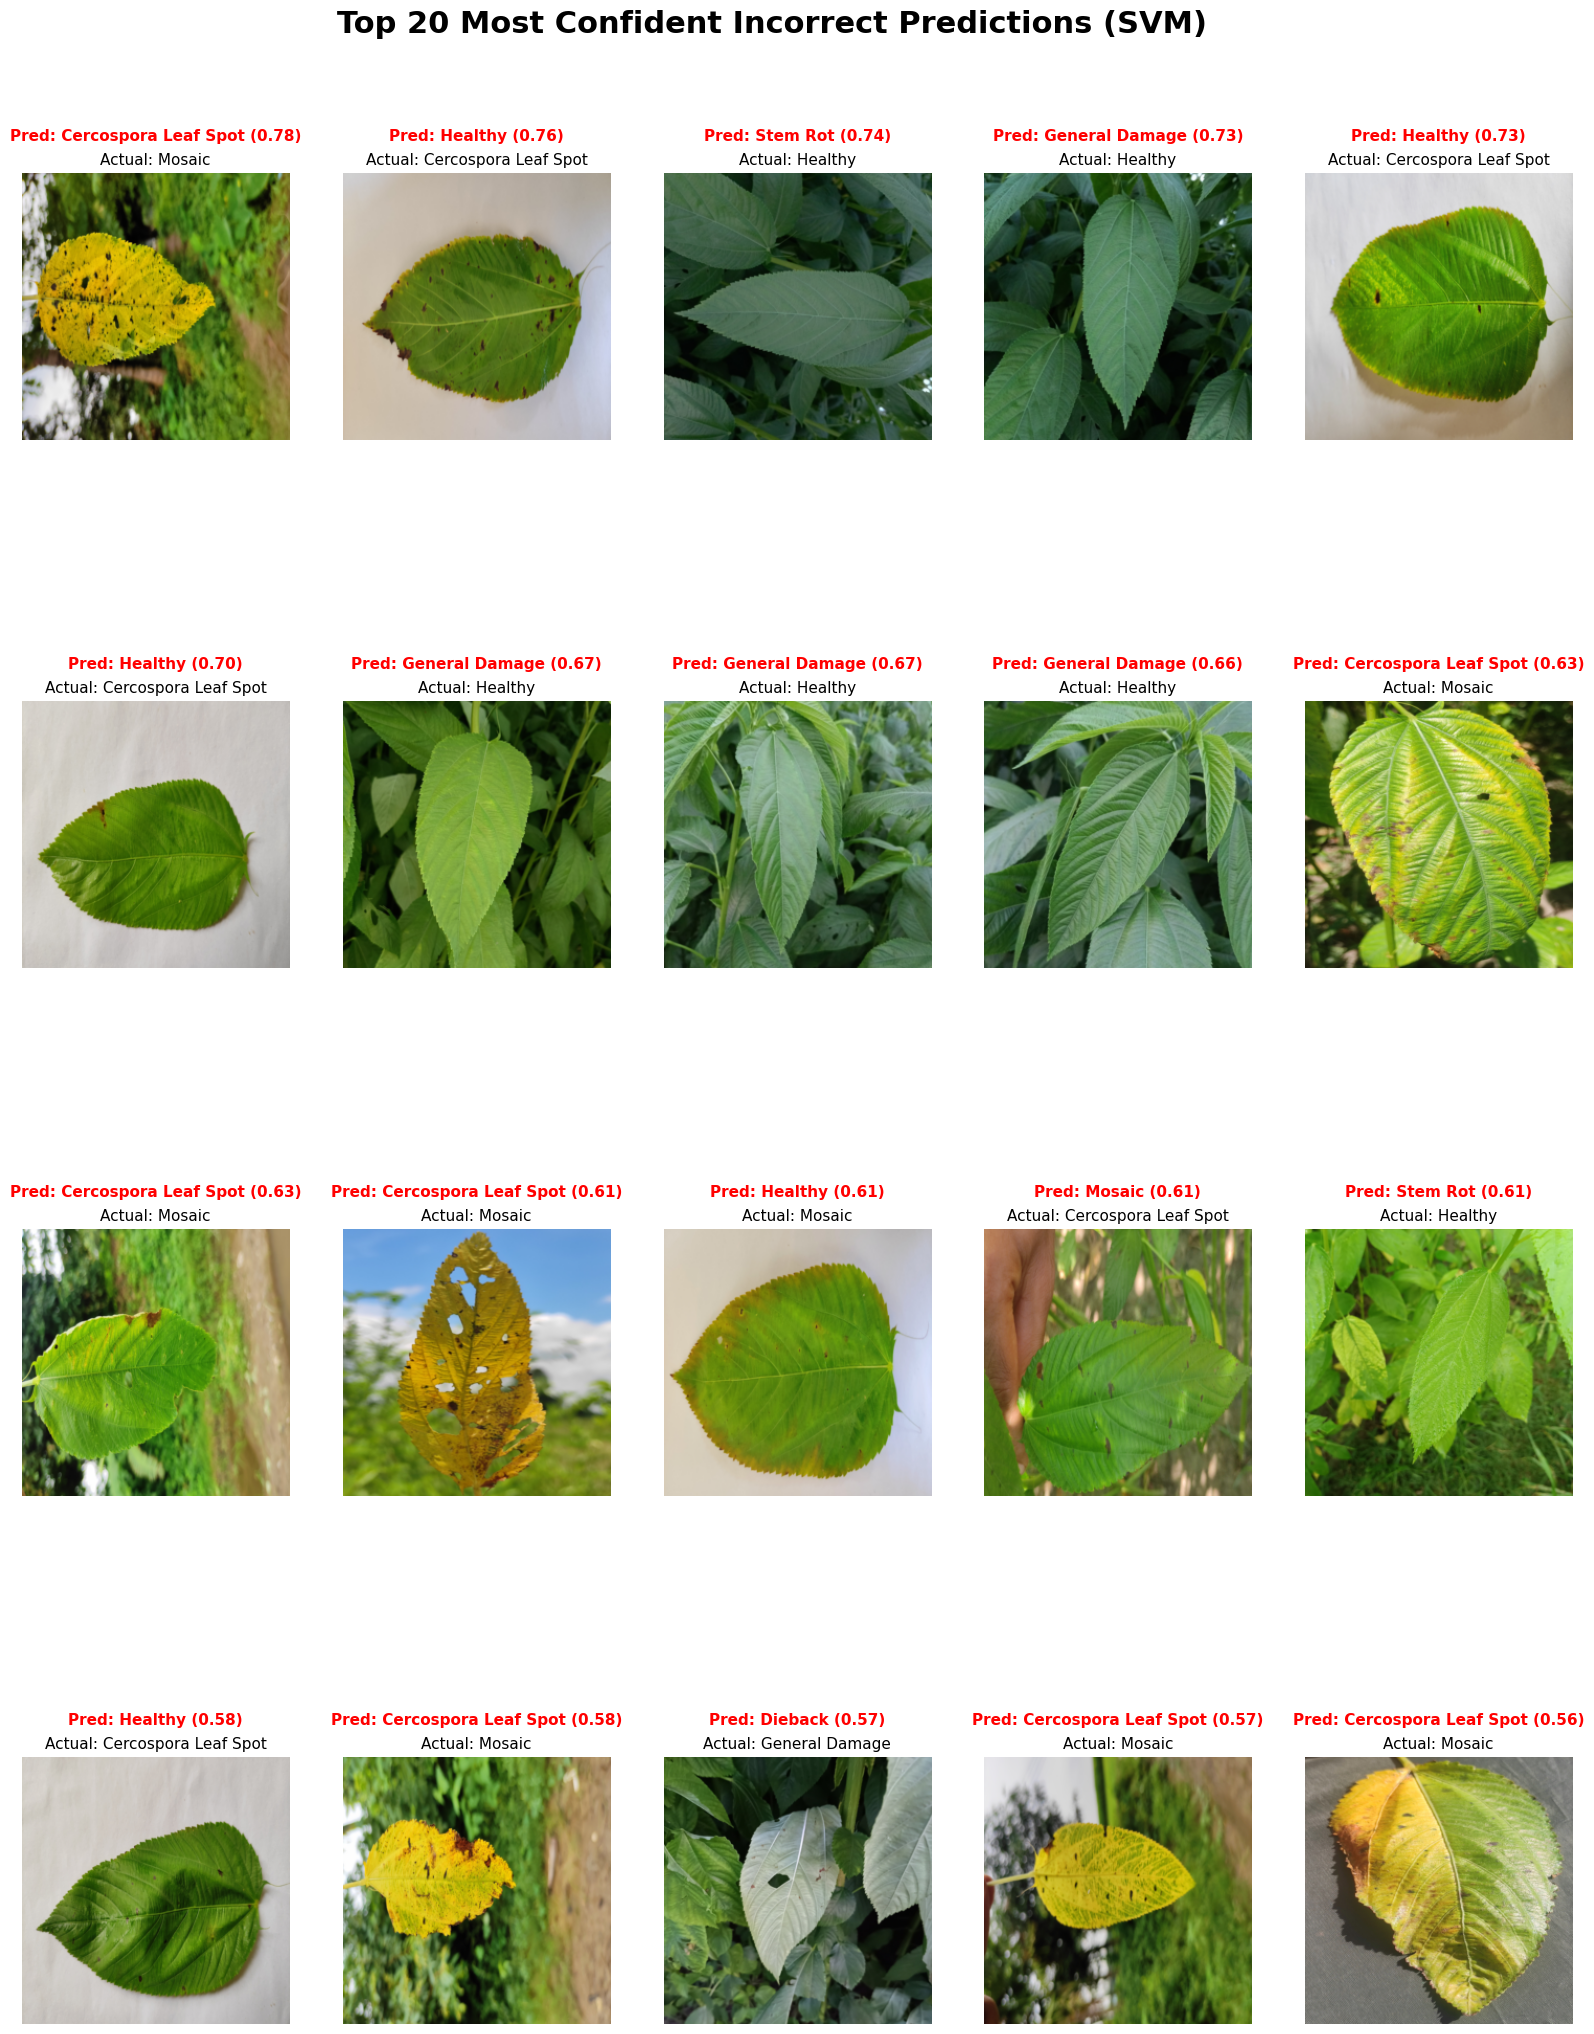

In [12]:
from jute_disease.utils.constants import IMAGE_SIZE
def plot_top_ml_errors(model_name, preds, probs, targets, dataset, top_k=20):
    is_wrong = preds != targets
    wrong_indices = np.where(is_wrong)[0]

    if len(wrong_indices) == 0:
        print(f"No errors found for {model_name}!")
        return

    wrong_probs = [probs[i, preds[i]] for i in wrong_indices]

    # sort by confidence desc
    n_display = min(top_k, len(wrong_indices))
    sorted_wrong = np.argsort(wrong_probs)[::-1][:n_display]
    top_wrong_idx = wrong_indices[sorted_wrong]

    ncols = 5
    nrows = int(np.ceil(n_display / ncols))

    plt.figure(figsize=(20, 5.5 * nrows))

    class_names = ["Cercospora Leaf Spot", "Dieback", "General Damage", "Healthy", "Mosaic", "Stem Rot"]

    for i, idx in enumerate(top_wrong_idx):
        img_array, label = dataset[idx]

        plt.subplot(nrows, ncols, i + 1)
        plt.imshow(img_array)

        ax_sub = plt.gca()

        # Pred text (red)
        ax_sub.text(0.5, 1.12, f"Pred: {class_names[preds[idx]]} ({probs[idx, preds[idx]]:.2f})",
                    color="red", fontsize=11, fontweight='bold', ha="center", transform=ax_sub.transAxes)

        # Actual text (black)
        ax_sub.text(0.5, 1.03, f"Actual: {class_names[targets[idx]]}",
                    color="black", fontsize=11, ha="center", transform=ax_sub.transAxes)

        plt.axis("off")

    plt.suptitle(f"Top {n_display} Most Confident Incorrect Predictions ({model_name})",
                 fontsize=22, fontweight='bold', y=0.98)

    # gap
    plt.subplots_adjust(top=0.92, bottom=0.05, hspace=0.6, wspace=0.2)

    save_path = f"artifacts/top_{model_name.lower().replace(' ', '_')}_errors.png"
    plt.savefig(save_path, bbox_inches="tight", dpi=300)
    plt.show()

# show images
TEST_DIR = "/content/jute-disease-detection/data/ml_split/val"

ml_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.Lambda(lambda x: np.array(x))
])
ml_test = ImageFolder(root=TEST_DIR, transform=ml_transform)

plot_top_ml_errors("Random Forest", rf_preds, rf_probas, y_val_labels, ml_test)
plot_top_ml_errors("SVM", svm_preds, svm_probas, y_val_labels, ml_test)

### Some Insights:
- The RF model misclassified `Cercospora Leaf Spots` the most.
- On the other hand, the SVM classifier misclassified Mosaic the most.
- It is worth noting that for both models, the top 20 most confident predictions primarily predicted the samples as `Healthy`.
  - Looking further into the images for these instances, it seems apparent from a non-expert perspective that they don't appear to be healthy leaves. This suggest that both model may have been focusing on a different set of features that it interpreted as being associated with `Healthy` Jute leaves.
  - Additionally, it is worth noting that majority of the top 20 cited images appear to have been collected from the same dataset given the similarities of orientation wherein the leaf is placed in a white background while the its apex faces to either the left or right.
- Taking into consideration the orientation and presentation of the leaves, a majority of the images appear to have come from the same dataset wherein they were all misclassified as `Healthy` by both models. This may suggest several probable causes such as both models are finding it difficult to use this particular set of data in differentiating between the six classes. It may also be possible that the model is particularly biased such that it struggles to find small defects in the jute leaf images in order to identify them as being affected by a disease.


### **1C: Latent Space Analysis**
Throughout our error analysis process, we've observed different instances of classes seemingly being misclassified, however, we currently lack two things: (1) a general idea of how the model sees the images from the perspective of the crafted features and (2) an understanding of the value of the crafted features in our models classification task. To address this, we will be employing two key strategies being (1) latent space analysis and (2) feature importance.



We begin with **Latent Space Analysis**, which is a method of which allows us to compress high-dimensional and complex data into a lower dimension such that it essentially provides us with a way of meaningfully representing our data points based on the features, relationships, and underlying patterns. For this section we will primarily be using T-distributed Stochastic Neighbor Embedding (t-SNE) and Uniform Manifold Approximation and Projection (UMAP).

Pre-reducing 8692 dims to 50 via PCA...
Reducing dimensions using t-SNE...


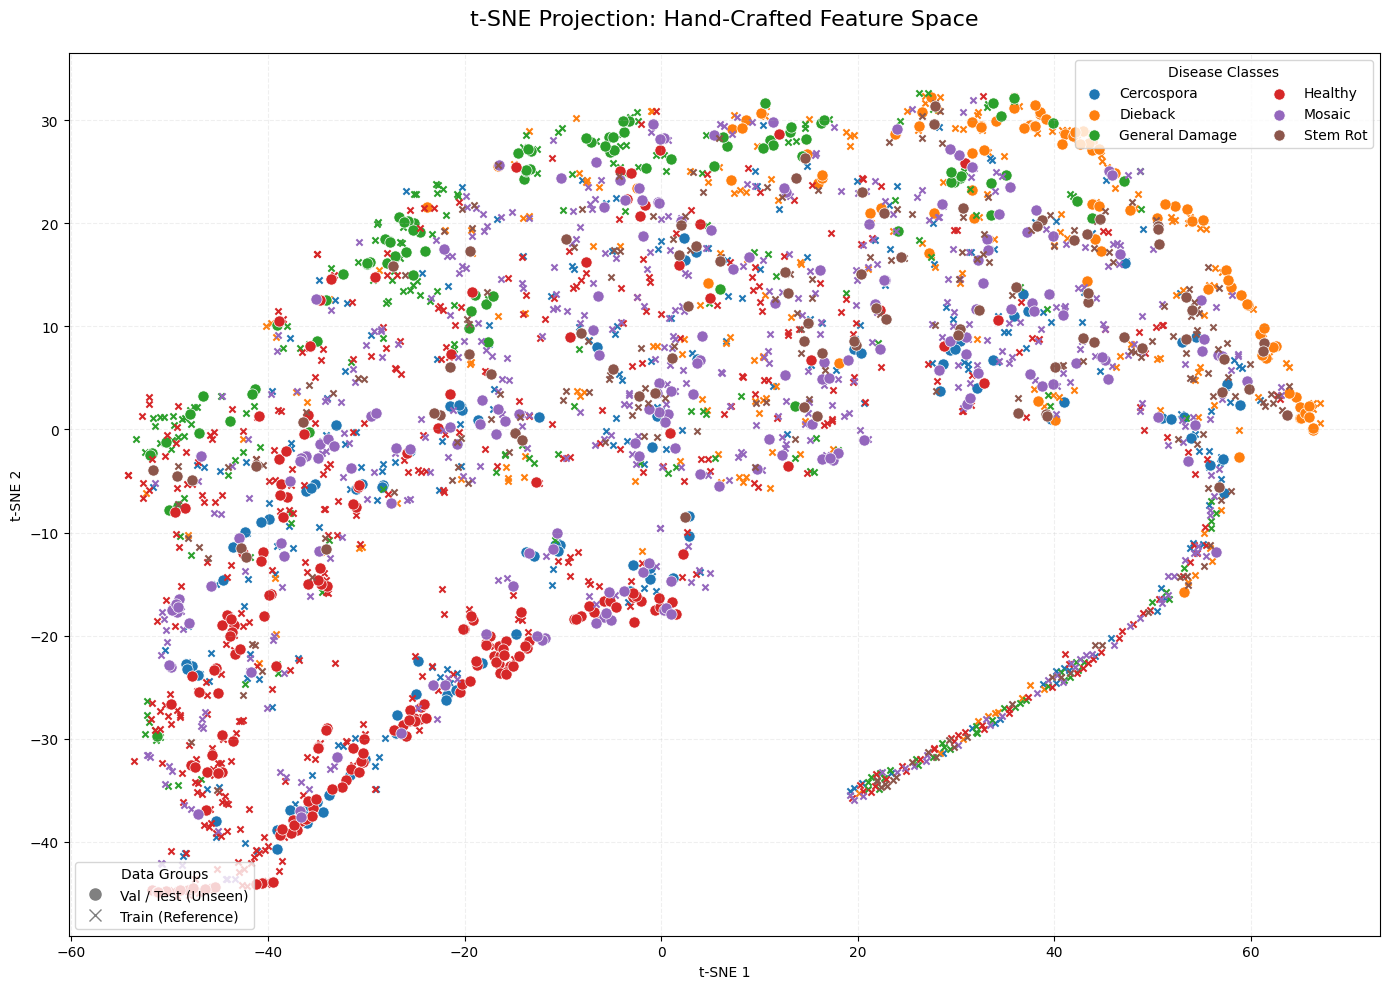

Reducing dimensions using UMAP...


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


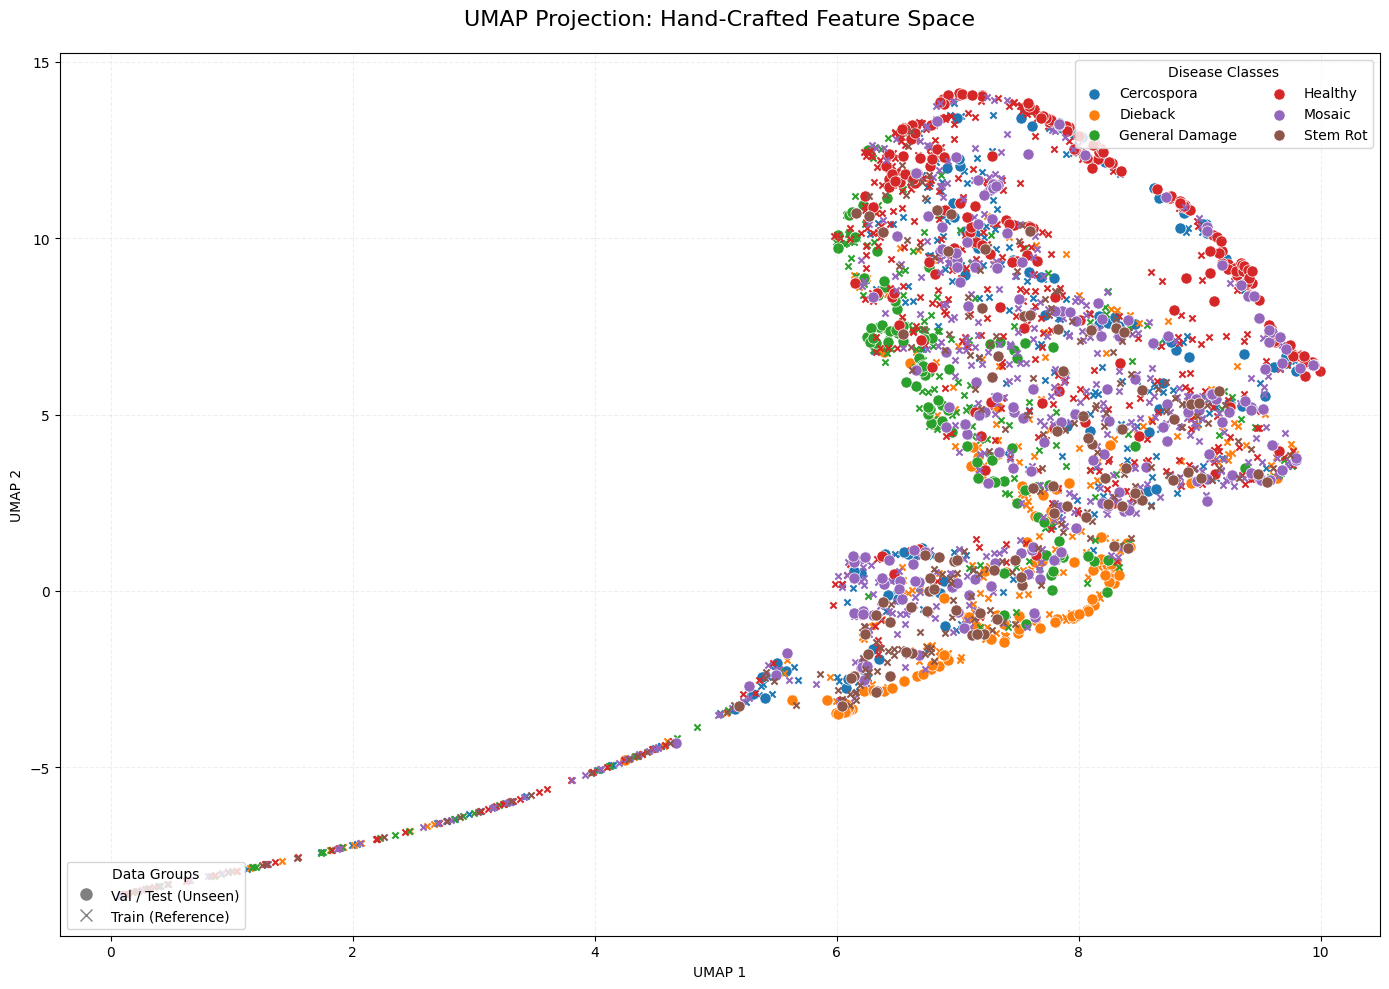

In [71]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from umap import UMAP
from matplotlib.lines import Line2D
from sklearn.decomposition import PCA

X_train = np.load(FEATURE_DIR / "craftedfeatureextractor_train_X.npy")
y_train = np.load(FEATURE_DIR / "craftedfeatureextractor_train_y.npy")
X_val   = np.load(FEATURE_DIR / "craftedfeatureextractor_val_X.npy")
y_val   = np.load(FEATURE_DIR / "craftedfeatureextractor_val_y.npy")
X_test  = np.load(FEATURE_DIR / "craftedfeatureextractor_test_X.npy")
y_test  = np.load(FEATURE_DIR / "craftedfeatureextractor_test_y.npy")

features = np.vstack([X_train, X_val, X_test])
targets = np.concatenate([y_train, y_val, y_test])
splits = np.array(["Train"] * len(y_train) + ["Val"] * len(y_val) + ["Eval"] * len(y_test))

class_names = ["Cercospora", "Dieback", "General Damage", "Healthy", "Mosaic", "Stem Rot"]

print(f"Pre-reducing {features.shape[1]} dims to 50 via PCA...")
features_pca = PCA(n_components=50, random_state=42).fit_transform(features)

def plot_latent_space(reducer_name="tsne"):
    # Setup reducer
    if reducer_name.lower() == "tsne":
        reducer = TSNE(n_components=2, perplexity=30, random_state=42, n_jobs=-1)
        title_suffix = "t-SNE"
    else:
        reducer = UMAP(n_neighbors=15, min_dist=0.1, random_state=42)
        title_suffix = "UMAP"

    print(f"Reducing dimensions using {title_suffix}...")
    feat_2d = reducer.fit_transform(features_pca)

    # plotting logic with UNIFIED marker for Val/Test
    plt.figure(figsize=(14, 10))
    colors = sns.color_palette("tab10", len(class_names))

    for i, cls in enumerate(class_names):
        # TRAIN SET (Reference Group)
        m_train = (targets == i) & (splits == "Train")
        plt.scatter(feat_2d[m_train, 0], feat_2d[m_train, 1],
                    color=colors[i], marker="x", s=20)

        # UNIFIED EVALUATION GROUP (Val + Test)
        m_unseen = (targets == i) & ((splits == "Val") | (splits == "Eval"))
        plt.scatter(feat_2d[m_unseen, 0], feat_2d[m_unseen, 1],
                    color=colors[i], marker="o", s=65,
                    edgecolors="white", linewidth=0.5, label=cls)

    split_legend = [
        Line2D([0], [0], marker="o", color="gray", lw=0, markersize=8, label="Val / Test (Unseen)"),
        Line2D([0], [0], marker="x", color="gray", lw=0, markersize=8, label="Train (Reference)"),
    ]

    leg1 = plt.legend(handles=split_legend, loc="lower left", title="Data Groups", frameon=True)
    plt.gca().add_artist(leg1)
    plt.legend(loc="upper right", title="Disease Classes", ncol=2, frameon=True)

    plt.title(f"{title_suffix} Projection: Hand-Crafted Feature Space", fontsize=16, pad=20)
    plt.xlabel(f"{title_suffix} 1")
    plt.ylabel(f"{title_suffix} 2")
    plt.grid(True, linestyle='--', alpha=0.2)
    plt.tight_layout()
    plt.show()

plot_latent_space("tsne")
plot_latent_space("umap")

Our t-SNE and UMAP projections above have provided us with the means to look into how the the instances for our data are related to one another. Upon initial inspection, we can see that the images classified as `Dieback`, `General Damage`, and `Healthy` somewhat appears to be closely clustered with one another given that we can see their dense groups being situated around the endges of our projections. However, `Cercospora Leaf Spots`, `Mosaic`, and `Stem Rot` appear to have a sparse distribution as the majority of their instances coincide with one another. Interestingly, this dynamic of sparsity with regards to `Cercospora` and `Mosaic` somewhat resembles the trends we have observed from our baseline models wherein they find it difficult to correctly distinguish these two classes. This may be due to the element of color being considered when identifying these. As our EDA and sampled images have demonstrated, `Cercospora` is identified by the presence of small brown lesions while `Mosaic` is characterized by yellow patches. We may need to try to understand how this feature of color is considered later through investigating feature importance of our crafted features.

Next we want to tackle **Feature Importance**, wherein we will be considering the handcrafted features, specifically: color (HSV),  texture (LBP, GLCM), and shape (HOG) features. In order to get an idea of what exactly we are looking at.

In [72]:
FEATURE_DIR = Path("/content/drive/MyDrive/artifacts/features/")

def count_features_from_npy(directory):
    npy_files = list(directory.glob("craftedfeatureextractor_test_X.npy"))

    sample_file = npy_files[0]

    features = np.load(sample_file, mmap_mode='r')

    n_samples, n_features = features.shape

    print(f"Feature Extraction Results")
    print(f"Total Instances:  {n_samples:,} images")
    print(f"Feature Vector:   {n_features:,} dimensions")

    return n_features

total_features = count_features_from_npy(FEATURE_DIR)

Feature Extraction Results
Total Instances:  360 images
Feature Vector:   8,692 dimensions


Given that our feature vector contains 8692 dimensions, it is important that we understand how such features affect the models prediction.

In [73]:
def plot_rf_feature_importance(rf_model, feature_names, top_n=20):
    classifier = rf_model.steps[-1][1]

    if not hasattr(classifier, 'feature_importances_'):
        print(f"The model {type(classifier).__name__} does not support feature_importances_.")
        return

    importances = classifier.feature_importances_

    if len(feature_names) != len(importances):
        print(f"Mismatch: Model has {len(importances)} features, but you provided {len(feature_names)} names.")
        feature_names = [f"Feature_{i}" for i in range(len(importances))]

    indices = np.argsort(importances)[-top_n:]

    plt.figure(figsize=(12, 8))
    plt.title(f"Top {top_n} Most Influential Features (Random Forest)", fontsize=14, fontweight='bold')
    plt.barh(range(len(indices)), importances[indices], align='center', color='skyblue', edgecolor='navy')
    plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
    plt.xlabel('Relative Importance Score', fontweight='bold')
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

In [74]:
def get_feature_names():
    color_names = [f"Color_{c}_{m}" for c in ['R', 'G', 'B'] for m in ['Mean', 'Std', 'Skew']]
    lbp_names = [f"LBP_Bin_{i}" for i in range(10)]
    hog_names = [f"HOG_{i}" for i in range(8673)]

    return color_names + lbp_names + hog_names

feature_names = get_feature_names()

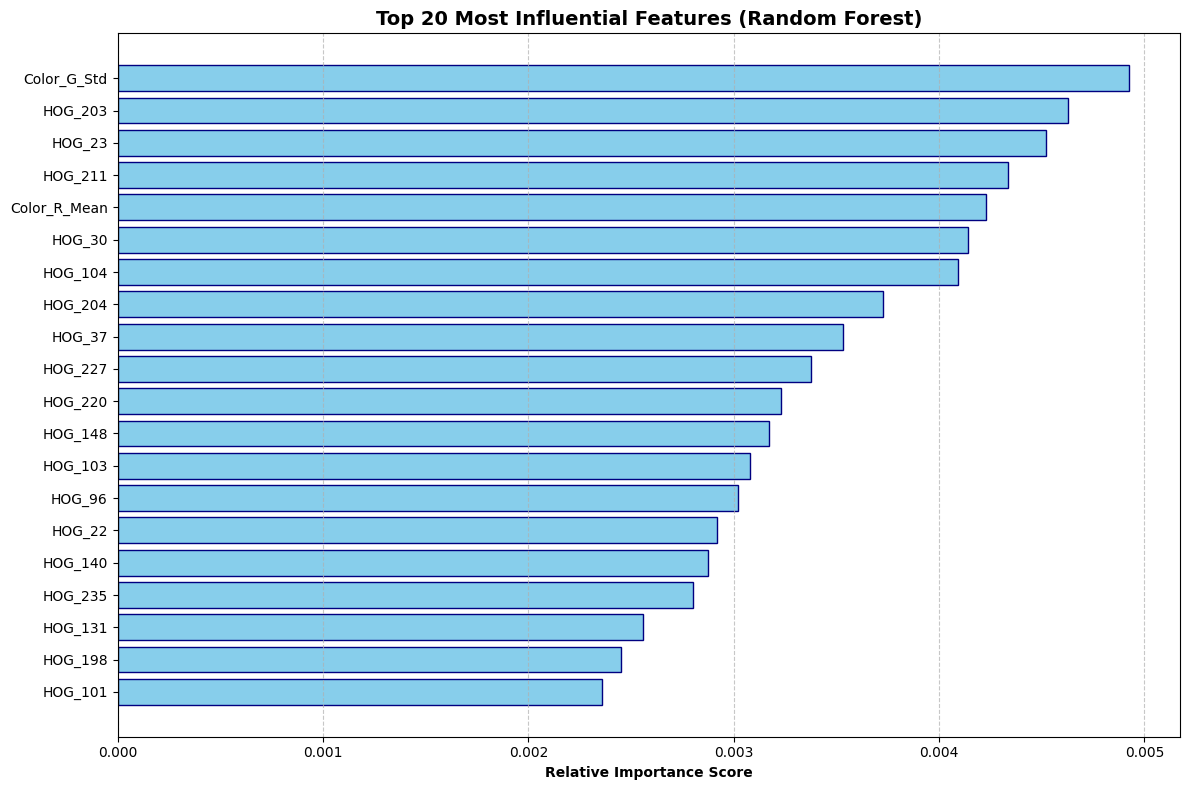

In [75]:
import numpy as np
import matplotlib.pyplot as plt

plot_rf_feature_importance(rf_model, feature_names, top_n=20)

Given the top 20 influential features for our baseline random forest, it's apparent that it is majorly composed of histogram of oriented gradients (HOG), which essentially represents the shape and structure in an image. Considering the classes we are using for our models, it is evident that it does play an important role given that our classes are characterized by presence of locallized spots, lesions, presence of holes, and the leave's shape.

On the other hand, it is worth noting that the standard deviation of the green color channel as well the mean of the red color channel is placed within the top five. With regards to color, it is reasonable to assume that the green color channel would be important given that our data is predominantly composed of green leaves which may result to a low standard deviation. We've seen from the EDA process, that some classification are characterized with relation to color. For instance, patches of brown lesions are attributed to `Cercospora Leaf Spots` and yellow flakes for `Mosaic`. When the presence of such patches appear in the image, there is a possibility that the standard deviation of the green color channel may become high. Additionally, given that the images are predominantly composed of the color green, it may be reasonable that the mean metric for the red color channel will often stay low. By having the presence of characterized spots such as yellow flakes and brown lesions, it's possible that this would lead to a much higher mean measured.

The afforementioned discussions are merely theories that are grounded by the assumptions we have gathered from our EDA. Going back to the t-SNE and UMAP projections, it is evident that the instances classified as `Cercospora Leaf Spots` and `Mosaic` are not captured as well as we would have hoped for given that their data points are dispersed. We may interpret this as a possible need to reconsider the processing step for our data with regards to color.

In [76]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score

# 1. Use the full training set (or a 20% slice for speed)
X_eval = X_train  # Since we only do 5 passes, we can use more data
y_eval = y_train

print("Calculating Grouped Feature Importance...")
baseline_f1 = f1_score(y_eval, svm_model.predict(X_eval), average='macro')

# 2. Define our Groups (Indices from your CraftedFeatureExtractor)
groups = {
    "Color Moments": (0, 6),
    "Color Histogram": (6, 518),
    "LBP (Texture)": (518, 544),
    "GLCM (Texture)": (544, 600),
    "HOG (Shape)": (600, X_eval.shape[1])
}

group_results = []

for name, (start, end) in groups.items():
    X_permuted = X_eval.copy()

    # Shuffle all features in this group at once
    for col in range(start, end):
        np.random.shuffle(X_permuted[:, col])

    # Measure the drop
    permuted_f1 = f1_score(y_eval, svm_model.predict(X_permuted), average='macro')
    importance = baseline_f1 - permuted_f1

    group_results.append({"Category": name, "Importance": importance})
    print(f"Finished {name}: Importance = {importance:.4f}")

# 3. Visualization
df_grouped = pd.DataFrame(group_results).sort_values(by="Importance", ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(df_grouped["Category"], df_grouped["Importance"], color='teal')
plt.gca().invert_yaxis()
plt.xlabel("Drop in F1 Macro Score (Higher = More Important)")
plt.title("SVM Importance by Feature Category (Grouped Shuffling)")
plt.grid(axis='x', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

print("\n--- Grouped Importance Summary ---")
print(df_grouped)

Calculating Grouped Feature Importance...
Finished Color Moments: Importance = 0.0005
Finished Color Histogram: Importance = 0.0255
Finished LBP (Texture): Importance = 0.0087


KeyboardInterrupt: 

## **Part 2: Hyperparameter Tuning**
For the tuning process, we will be tuning the hyperparameters for both of our baseline RF and SVM models.



### 2A: Random Forest Tuning
For the RF model, we will be using a grid search on the following hyperparameters:
- `max_depth`: None, 15, 25
- `min_samples_leaf`: 2, 5, 10
- `max_features`: sqrt, log2
- `n_estimators`: 100, 200, 500

For the `max_depth`, we wanted to reduce it to a much lower number in order to account for the possibility of the model simply memorizing the features as there are instances wherein it may capture insignificant features as important in classifying the instance.

We added higher values for the `min_samples_leaf`so as to account for the possibility of outlier instances acting as a representative for a classification. Given that the Top 20 most confident error that we plotted earlier had a lot of misclassified `Cercospora` and `Mosaic` as `Healthy`, the idea would be that higher values of `min_samples_leaf` would introduce bias to our model.

The addition of a log2 option for `max_features` allows a significant reduction in the number of features as compared to the sqrt function. By reducing the number of features a tree is allowed to look into, it forces the trees in our RF to have a more focused approach on how it looks into the images during training. Although, this may not be the best approach given that the texture and shape severely outnumbers the number of color features all the while we have classes that may rely on this. However, it may still be worth testing for.

Lastly, we introduced higher values for the `n_estimators` given that our model is finding it difficult to differentiate between instances with somewhat subtle or interchangeable characteristics such as in the case of `Cercospora` and `Mosaic` instances being classified as `Healthy`. By providing higher value options, we can allow our RF model to sample more features, therefore possibly having a better intuition on the features.  

Shown below are the default hyperparameters used for the baseline RF model.

In [ ]:
baseline_params = rf_model.steps[-1][1].get_params()

print("Current Baseline Hyperparameters for Random Forest")
for param, value in baseline_params.items():
    if param in ['n_estimators', 'max_depth', 'min_samples_split', 'max_features']:
        print(f"{param}: {value}")

Shown below is the commented out tuning grid search script for the random forest's hyperparameters.

In [ ]:
# import pandas as pd
# import joblib
# import numpy as np
# from pathlib import Path
# from sklearn.model_selection import GridSearchCV, PredefinedSplit
# from sklearn.pipeline import Pipeline
# from sklearn.preprocessing import StandardScaler
# from sklearn.ensemble import RandomForestClassifier
# from sklearn.metrics import precision_recall_fscore_support, accuracy_score
# import wandb

# logger = get_logger("RF_GRID_Tuning")

# # # 1. Path Configuration
# FEATURE_DIR = Path("/content/drive/MyDrive/artifacts/features/")
# MODEL_DIR = Path("artifacts/ml_models")
# MODEL_DIR.mkdir(parents=True, exist_ok=True)

# def run_rf_tuning():
#     # 2. Load Data (Loading all three splits)
#     logger.info("Loading features...")
#     X_train = np.load(FEATURE_DIR / "craftedfeatureextractor_train_X.npy")
#     y_train = np.load(FEATURE_DIR / "craftedfeatureextractor_train_y.npy")
#     X_val = np.load(FEATURE_DIR / "craftedfeatureextractor_val_X.npy")   # The Fixed Judge
#     y_val = np.load(FEATURE_DIR / "craftedfeatureextractor_val_y.npy")
#     X_test = np.load(FEATURE_DIR / "craftedfeatureextractor_test_X.npy") # The Final Exam
#     y_test = np.load(FEATURE_DIR / "craftedfeatureextractor_test_y.npy")

#     # 3. Aligning with DL Logic: Setup PredefinedSplit
#     # We create a mapping: -1 for training rows, 0 for the validation rows.
#     # This ensures GridSearchCV ONLY uses X_val to pick the best parameters.
#     indices = np.concatenate([
#         np.full(X_train.shape[0], -1),
#         np.full(X_val.shape[0], 0)
#     ])
#     pds = PredefinedSplit(test_fold=indices)

#     # Merge them for the .fit() method
#     X_full_train = np.vstack((X_train, X_val))
#     y_full_train = np.concatenate((y_train, y_val))

#     params = {
#         'classifier__n_estimators': [100, 200, 500],
#         'classifier__max_depth': [None, 15, 25],
#         'classifier__min_samples_split': [2, 5, 10],
#         'classifier__max_features': ['sqrt', 'log2']
#     }

#     with wandb.init(
#         entity=WANDB_ENTITY,
#         project=WANDB_PROJECT,
#         job_type="tuning",
#         name="rf-val-split-aligned",
#         tags=["experiment", "rf", "fixed-val"],
#         config=params
#     ) as run:

#         pipeline = Pipeline([
#             ('scaler', StandardScaler()),
#             ('classifier', RandomForestClassifier(random_state=42, oob_score=True, n_jobs=-2))
#         ])

#         # 4. Grid Search (Using pds instead of cv=5)
#         logger.info(f"Grid Search using Fixed Validation Set (Matching DL approach)...")
#         search = GridSearchCV(pipeline, params, cv=pds, scoring='f1_macro', n_jobs=-2, verbose=1)
#         search.fit(X_full_train, y_full_train)

#         # 5. Extract Best Metrics (VALIDATION)
#         # This is now equivalent to the 'val_loss' check in your DL script
#         best_model = search.best_estimator_
#         val_f1 = search.best_score_

#         # 6. Final Evaluation (TEST)
#         y_test_pred = best_model.predict(X_test)
#         y_test_probas = best_model.predict_proba(X_test)

#         t_prec, t_rec, t_f1, _ = precision_recall_fscore_support(y_test, y_test_pred, average='macro')
#         t_acc = accuracy_score(y_test, y_test_pred)

#         # 7. Aggregate Results (Matching _aggregate_metrics logic)
#         results_df = pd.DataFrame(search.cv_results_)
#         results_df['params'] = results_df['params'].astype(str) # Prevent WandB type error

#         # Save local CSV for parity with your DL logs
#         results_path = MODEL_DIR / "rf_grid_metrics_summary.csv"
#         results_df.to_csv(results_path, index=False)

#         # 8. Unified Logging
#         wandb.log({
#             "best_params": str(search.best_params_),
#             "val_f1_macro": val_f1,         # This is the "Selection Basis"
#             "test_acc": t_acc,
#             "test_f1": t_f1,
#             "performance_report": wandb.Table(dataframe=results_df[['params', 'mean_test_score', 'rank_test_score']])
#         })

#         # 9. Save Artifacts
#         model_path = MODEL_DIR / "rf_crafted_champion.joblib"
#         joblib.dump(best_model, model_path)

#         artifact = wandb.Artifact("rf-champion", type="model")
#         artifact.add_file(str(model_path))
#         artifact.add_file(str(results_path)) # Include the CSV summary in the artifact
#         run.log_artifact(artifact)

#         logger.info(f"Done. Val F1: {val_f1:.4f} | Test F1: {t_f1:.4f}")

#     wandb.finish()

# if __name__ == "__main__":
#     run_rf_tuning()

By this point, we have successfully tuned our RF model. A previous WANDB run may be accessed through this link: [WANDB Run](https://wandb.ai/grade-descent/jute-disease-detection/runs/5ujoflpj?nw=nwuserimmanumali12).

In [ ]:
import ast
import pandas as pd
import wandb

def get_rf_winner(path):
    api = wandb.Api()
    run = api.run(path)

    summary = run.summary
    best_params_raw = summary.get('best_params', "{}")

    # --- THE FIX ---
    # If it's a string (which it is, because we stringified it), convert it back to a dict
    if isinstance(best_params_raw, str):
        try:
            best_params_dict = ast.literal_eval(best_params_raw)
        except (ValueError, SyntaxError):
            # Fallback in case the string is malformed
            logger.error("Could not parse best_params string.")
            best_params_dict = {}
    else:
        best_params_dict = best_params_raw
    # ---------------

    # Filtering for the classifier params and cleaning names
    clean_params = {
        k.replace('classifier__', ''): v
        for k, v in best_params_dict.items()
    }

    print(f"RF Champion: {run.name}")
    # Setting an index makes the display look cleaner in Colab
    return pd.DataFrame(list(clean_params.items()), columns=['Hyperparameter', 'Value'])

# Execute
# Replace frlkna4c with your actual run ID if it changes
rf_df = get_rf_winner(f"{WANDB_ENTITY}/{WANDB_PROJECT}/frlkna4c")
display(rf_df)

### 2B: Support Vector Machine Tuning
For the SVM model, we opted to using random search instead of grid search for the main reason of being computationally expensive. Given the large volume of our crafted feature dimension (n=8692), the kernel matrix calculation alone would take a far greater amount of time as compared to using random search. Additionally, given that a random search still performs well despite not being as systematic compared to the grid search, we decided to opt for this. The random search is configured to follow 15 iterations and 5 cross-validation. The hyperparameters selected and its ranges are as follows:
- `c`: loguniform(1, 1e3)
- `gamma`: scale, 0.1, 0.01, 0.001
- `kernel`: rbf, poly
- `degree`: 3


In [ ]:
# Assuming svm_model is your loaded SVM Pipeline
svm_baseline_params = svm_model.steps[-1][1].get_params()

print("--- Current Baseline Hyperparameters for SVM ---")
# These are the core parameters that determine the decision boundary shape
core_svm_params = ['C', 'kernel', 'gamma', 'degree', 'class_weight', 'probability']

for param, value in svm_baseline_params.items():
    if param in core_svm_params:
        print(f"{param:15}: {value}")

Shown below is the commented out tuning grid search script for the support vector machine's hyperparameters.

In [ ]:

# import pandas as pd
# import joblib
# import numpy as np
# from pathlib import Path
# from scipy.stats import loguniform
# from sklearn.model_selection import RandomizedSearchCV, PredefinedSplit
# from sklearn.pipeline import Pipeline
# from sklearn.preprocessing import StandardScaler
# from sklearn.svm import SVC
# from sklearn.metrics import precision_recall_fscore_support, accuracy_score
# import wandb
# logger = get_logger("SVM_Random_Tuning")

# # # 1. Path Configuration
# FEATURE_DIR = Path("/content/drive/MyDrive/artifacts/features/")
# MODEL_DIR = Path("artifacts/ml_models")
# MODEL_DIR.mkdir(parents=True, exist_ok=True)

# def run_svm_tuning():
#     # 2. Load Data
#     logger.info("Loading features for SVM Fixed-Val Tuning...")
#     X_train = np.load(FEATURE_DIR / "craftedfeatureextractor_train_X.npy")
#     y_train = np.load(FEATURE_DIR / "craftedfeatureextractor_train_y.npy")
#     X_val = np.load(FEATURE_DIR / "craftedfeatureextractor_val_X.npy")   # Added Val
#     y_val = np.load(FEATURE_DIR / "craftedfeatureextractor_val_y.npy")
#     X_test = np.load(FEATURE_DIR / "craftedfeatureextractor_test_X.npy")
#     y_test = np.load(FEATURE_DIR / "craftedfeatureextractor_test_y.npy")

#     # 3. Setup PredefinedSplit (Aligning with DL/RF logic)
#     indices = np.concatenate([np.full(X_train.shape[0], -1), np.full(X_val.shape[0], 0)])
#     pds = PredefinedSplit(test_fold=indices)

#     X_full_train = np.vstack((X_train, X_val))
#     y_full_train = np.concatenate((y_train, y_val))

#     # 4. Hyperparameter Distributions
#     param_dist = {
#         'classifier__C': loguniform(1, 1e3),
#         'classifier__gamma': ['scale', 0.1, 0.01, 0.001],
#         'classifier__kernel': ['rbf', 'poly'],
#         'classifier__degree': [3],
#     }

#     with wandb.init(
#         entity=WANDB_ENTITY,
#         project=WANDB_PROJECT,
#         job_type="tuning",
#         name="svm-val-split-aligned",
#         tags=["experiment", "svm", "fixed-val"],
#         config={"n_iter": 15}
#     ) as run:

#         pipeline = Pipeline([
#             ('scaler', StandardScaler()),
#             ('classifier', SVC(
#                 probability=True,
#                 class_weight='balanced',
#                 random_state=42
#             ))
#         ])

#         # 5. Randomized Search with pds
#         logger.info(f"SVM Randomized Search using Fixed Validation Set...")
#         search = RandomizedSearchCV(
#             pipeline,
#             param_distributions=param_dist,
#             n_iter=15,
#             cv=pds,        # Use PredefinedSplit
#             scoring='f1_macro',
#             n_jobs=-2,     # Leave 1 core for Colab/WandB
#             verbose=1,
#             random_state=42
#         )
#         search.fit(X_full_train, y_full_train)

#         # 6. Performance Artifact (Saves all 15 iterations)
#         results_df = pd.DataFrame(search.cv_results_)
#         results_df['params'] = results_df['params'].astype(str) # Prevent type-errors
#         results_path = MODEL_DIR / "svm_tuning_results.csv"
#         results_df.to_csv(results_path, index=False)

#         # 7. Final Evaluation
#         best_model = search.best_estimator_
#         val_f1 = search.best_score_

#         y_test_pred = best_model.predict(X_test)
#         y_test_probas = best_model.predict_proba(X_test)

#         t_prec, t_rec, t_f1, _ = precision_recall_fscore_support(y_test, y_test_pred, average='macro')
#         t_acc = accuracy_score(y_test, y_test_pred)

#         # 8. Unified Logging
#         wandb.log({
#             "best_params": str(search.best_params_),
#             "val_f1_macro": val_f1,
#             "test_acc": t_acc,
#             "test_f1": t_f1,
#             "performance_report": wandb.Table(dataframe=results_df[['params', 'mean_test_score', 'rank_test_score']])
#         })

#         # 9. Visualizations
#         jute_classes = ["Cercospora", "Dieback", "General Damage", "Healthy", "Mosaic", "Stem Rot"]
#         wandb.log({
#             "conf_mat": wandb.plot.confusion_matrix(
#                 probs=None, y_true=y_test, preds=y_test_pred, class_names=jute_classes
#             ),
#             "pr_curve": wandb.plot.pr_curve(y_test, y_test_probas, labels=jute_classes),
#         })

#         # 10. Save Model Artifact
#         save_path = MODEL_DIR / "svm_crafted_champion.joblib"
#         joblib.dump(best_model, save_path)

#         artifact = wandb.Artifact("svm-champion", type="model")
#         artifact.add_file(str(save_path))
#         artifact.add_file(str(results_path))
#         run.log_artifact(artifact)

#         logger.info(f"Done. Val F1: {val_f1:.4f} | Test F1: {t_f1:.4f}")

#     wandb.finish()

# if __name__ == "__main__":
#     run_svm_tuning()

In [ ]:
import pandas as pd
import wandb
import numpy as np

def get_svm_winner(path):
    api = wandb.Api()
    run = api.run(path)

    summary = run.summary
    best_params_raw = summary.get('best_params', "{}")

    # --- THE ROBUST FIX ---
    if isinstance(best_params_raw, str):
        try:
            # We provide a 'namespace' so eval knows what 'np' and 'nan' are
            # This is much more flexible for Scikit-Learn strings
            safe_dict = {"np": np, "nan": np.nan, "None": None}
            best_params_dict = eval(best_params_raw, {"__builtins__": {}}, safe_dict)
        except Exception as e:
            print(f"Extraction failed for {run.name}: {e}")
            # Final fallback: just return the raw string in a dataframe so you can see it
            return pd.DataFrame([{"Error": "Manual Inspection Required", "Raw String": best_params_raw}])
    else:
        best_params_dict = best_params_raw
    # -----------------------

    clean_params = {
        k.replace('classifier__', ''): v
        for k, v in best_params_dict.items()
    }

    print(f"SVM Champion: {run.name}")
    return pd.DataFrame(list(clean_params.items()), columns=['Hyperparameter', 'Value'])

# Execute
svm_df = get_svm_winner(f"{WANDB_ENTITY}/{WANDB_PROJECT}/huhqb6pb")
display(svm_df)

## 2C: Error Analysis
Given that we have successfully tuned both models, it's time for us to reperform our error analysis so that we can compare their baseline and tuned versions. Specifically, we will be going through their confusion matrix, classification metrics, and top confident errors.

We start of with the RF models. Run the code cells below for our setup.

In [ ]:
# Setup for tuned RF
run = wandb.init(project=WANDB_PROJECT, job_type="evaluation")
artifact = run.use_artifact('rf-champion:latest', type='model')
artifact_dir = artifact.download()

model_path = f"{artifact_dir}/rf_crafted_champion.joblib"
rf_champion = joblib.load(model_path)

print("Random Forest Champion loaded successfully from W&B!")

In [ ]:
def plot_comparison_cm(y_true, y_pred_baseline, y_pred_tuned, model_name="SVM"):
    """
    Plots side-by-side confusion matrices using raw counts and n-size labels.
    """
    jute_classes = ["Cercospora", "Dieback", "General Damage", "Healthy", "Mosaic", "Stem Rot"]

    cm_base = confusion_matrix(y_true, y_pred_baseline)
    cm_tuned = confusion_matrix(y_true, y_pred_tuned)

    class_totals = cm_base.sum(axis=1)
    new_labels = [f"{cls}\n(n={total})" for cls, total in zip(jute_classes, class_totals)]

    fig, axes = plt.subplots(1, 2, figsize=(20, 8))

    # Plot Baseline (Raw Counts)
    sns.heatmap(cm_base, annot=True, fmt='g', cmap='Blues', ax=axes[0],
                xticklabels=jute_classes, yticklabels=new_labels)
    axes[0].set_title(f"Baseline {model_name}: Correct vs. Confused Counts\n(Default Parameters)",
                      fontsize=14, pad=20)
    axes[0].set_ylabel('Actual Disease (Ground Truth)', fontweight='bold')
    axes[0].set_xlabel('Predicted Disease', fontweight='bold')

    # Plot Tuned (Raw Counts)
    sns.heatmap(cm_tuned, annot=True, fmt='g', cmap='Greens', ax=axes[1],
                xticklabels=jute_classes, yticklabels=new_labels)
    axes[1].set_title(f"Tuned {model_name} Champion: Correct vs. Confused Counts\n(Optimized Parameters)",
                      fontsize=14, pad=20)
    axes[1].set_ylabel('Actual Disease (Ground Truth)', fontweight='bold')
    axes[1].set_xlabel('Predicted Disease', fontweight='bold')

    plt.tight_layout()
    plt.savefig(f"artifacts/{model_name.lower()}_tuning_comparison_counts.png", dpi=300)
    plt.show()

In [ ]:

jute_classes = ["Cercospora", "Dieback", "General Damage", "Healthy", "Mosaic", "Stem Rot"]

y_pred_base = rf_model.predict(X_test)
y_pred_tuned = rf_champion.predict(X_test)

plot_comparison_cm(
    y_true=y_test_labels,
    y_pred_baseline=y_pred_base,
    y_pred_tuned=y_pred_tuned,
    model_name="Random Forest"
)




The figure above shows a comparison between the baseline and tuned Random forest model. The tuned model was somewhat able to increase the per-class accuracy, it shows that despite the hyperparameter tuning, the model still finds it difficult to correctly classify `Cercospora Leaf Spots` and `Stem Rot`. This result may suggest that improving model per-class accuracy may require improvements in other areas of the model.

In [ ]:
runs_to_fetch = {
    "Tuned Random Forest": "frlkna4c",
    "Tuned SVM": "huhqb6pb"
}


def get_test_metrics(run_dict):
    api = wandb.Api()
    results = []

    for model_name, run_id in run_dict.items():
        try:
            run_path = f"{WANDB_ENTITY}/{WANDB_PROJECT}/{run_id}"
            run = api.run(run_path)

            metrics = {
                "Model": model_name,
                "Test Accuracy": run.summary.get("test_acc", "N/A"),
                "Test F1 (Macro)": run.summary.get("test_f1", "N/A")
            }
            results.append(metrics)

        except Exception as e:
            print(f"Error fetching run {run_id}: {e}")

    return pd.DataFrame(results)

df_final_metrics = get_test_metrics(runs_to_fetch)

styled_df = df_final_metrics.style.format({
    "Test Accuracy": "{:.4f}" if isinstance(df_final_metrics["Test Accuracy"].iloc[0], float) else "{}",
    "Test F1 (Macro)": "{:.4f}" if isinstance(df_final_metrics["Test F1 (Macro)"].iloc[0], float) else "{}"
})

display(styled_df)

In [ ]:
rf_artifact = api.artifact(f"{WANDB_ENTITY}/{WANDB_PROJECT}/rf-champion:latest")
rf_dir = rf_artifact.download()
tuned_rf_model = joblib.load(Path(rf_dir) / "rf_crafted_champion.joblib")

svm_artifact = api.artifact(f"{WANDB_ENTITY}/{WANDB_PROJECT}/svm-champion:latest")
svm_dir = svm_artifact.download()
tuned_svm_model = joblib.load(Path(svm_dir) / "svm_crafted_champion.joblib")

tuned_rf_preds = tuned_rf_model.predict(X_test)
tuned_svm_preds = tuned_svm_model.predict(X_test)

tuned_rf_probas = tuned_rf_model.predict_proba(X_test)
tuned_svm_probas = tuned_svm_model.predict_proba(X_test)


In [ ]:
rf_metrics_df = generate_metrics_table(y_test, rf_preds, "Baseline Random Forest")
tuned_rf_metrics_df = generate_metrics_table(y_test, tuned_rf_preds, "Tuned Random Forest")


Looking over the classification metrics, it seems that minimal changes occured between the baseline and tune models' accuracy. For the precision however, `Stem Rot` achieved a 100% precision while having a slight decrease in the recall. This suggests that our model has become more skeptic with regards to classifying such instances. On the other hand, `Mosaic` had a noticable increase in recall while `Cercospora` has a decrease. This dynamic between the two classes with regards to their classification metrics and the confusion matrix changes shows us that the model continues to struggle in correctly distinguishing these two. This suggests that despit the hyperparameter tuning done on the RF model, the solution may be explored through a different approach that investigates and targets how `Cercospora` and `Mosaic` can be distinguished.

### Tuned SVM Confusion Matrix and Analysis

In [ ]:

run = wandb.init(project=WANDB_PROJECT, job_type="evaluation")

artifact = run.use_artifact('grade-descent/jute-disease-detection/svm-champion:latest', type='model')
artifact_dir = artifact.download()

model_path = f"{artifact_dir}/svm_crafted_champion.joblib"
svm_champion = joblib.load(model_path)

print("Support Vector Machine Champion loaded successfully from W&B!")

In [ ]:
def plot_tuned_svm_cm(model, X, y, class_names):
    y_pred = model.predict(X)

    cm = confusion_matrix(y, y_pred, normalize='true')

    plt.figure(figsize=(12, 10))

    sns.heatmap(cm, annot=True, fmt='.1%', cmap='Oranges',
                xticklabels=class_names, yticklabels=class_names,
                annot_kws={"size": 11}, cbar_kws={'label': 'Fractions of Predictions'})

    plt.title("Confusion Matrix: Tuned Support Vector Machine (Hand-Crafted Features)", fontsize=16, fontweight='bold', y=1.02)
    plt.xlabel("Predicted Disease Class", fontsize=12, fontweight='bold')
    plt.ylabel("Actual Disease Class", fontsize=12, fontweight='bold')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()

    plt.savefig("artifacts/svm_tuned_confusion_matrix_orange.png", dpi=300, bbox_inches='tight')
    plt.show()
jute_classes = ["Cercospora", "Dieback", "General Damage", "Healthy", "Mosaic", "Stem Rot"]

y_pred_base = svm_model.predict(X_test)
y_pred_tuned = svm_champion.predict(X_test)

plot_comparison_cm(
    y_true=y_test_labels,
    y_pred_baseline=y_pred_base,
    y_pred_tuned=y_pred_tuned,
    model_name="Support Vector Machines"
)




In [ ]:
tuned_svm_metrics_df = generate_metrics_table(y_test, tuned_svm_preds, "Tuned SVM")
svm_metrics_df = generate_metrics_table(y_test, svm_preds, "Baseline SVM")

Looking over classification metrics, we can see that for accuracy, only `Dieback` had a noticable decrease. additionally, its F1-score took a huge dip wherein it decreased by approximately 27%. On the other hand, the precision for `Cercospora Leaf Spots` had an approximate 18% increase while its recall had a 38% decrease. Additionally, the recall value for `Mosaic` had decreased by almost 15%. This suggest that there is a persisitent gap with regards to classifying `Cercospora` and `Mosaic` that weren't solved by the hyperparameter tuning for this SVM and the RF model. This further reinforces that idea that addressing this issue may require the for us to put our focus in targeting how the features of these two classes are considered by our models.  

### Tuned Top Confident Errors

In [ ]:
plot_top_ml_errors("Tuned Random Forest", tuned_rf_preds, tuned_rf_probas, y_test_labels, ml_test)
plot_top_ml_errors("Tuned Support Vector Machines", tuned_svm_preds, tuned_svm_probas, y_test_labels, ml_test)

Looking into the both the tuned RF and SVM models' top most confident misclassifications, both seem to have been able to tackle its problem of often misclassifying `Mosaic` classes with high confidence. Additionally, it appears to be more skeptical with classifying the images as `Healthy` given that the baseline models were so confident in misclassiying the classes that are not `Healthy` as such. However, it would appear that it still struggles to correctly classify `Cercospora Leaf Spots` and `Mosaic` given that it still often intechanges the two with a high confidence.

## **Part 3: Conclusion**  

To conclude, our analysis has led us to have our Tuned SVM model that uses crafted features as the champion model for our classical machine learning models. Despite our fine tuning process, an evident weakness for both the tuned RF and SVM is the mix-up that occurs in classifying `Cercospora Leaf Spots` and `Mosaic` images. Given that these two classes are characterized by an element that is attributed to color (brown lesions for `Cercospora` and yellow patches). Looking at the sampled images from the EDA and the top most confident errors, we think this is because such classified images look as though they contain both characteristics which provides us with an insight on how it struglles for such instances. We may try to look further into this subject on the Deep Learning counterpart of this notebook if this problem continues to persist.